
#**Chapter 5 questions 5 and 6**

In [ ]:
import pandas as pd
import numpy as np

import math
import seaborn as sns


from matplotlib.pyplot import subplots
import itertools
import time
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.api import OLS
import sklearn. model_selection as skm
import sklearn. linear_model as skl
from sklearn. preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
!pip install ISLP
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from functools import partial
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

from sklearn. pipeline import Pipeline
from sklearn. decomposition import PCA
from sklearn. cross_decomposition import PLSRegression
from ISLP.models import \
(Stepwise ,
sklearn_selected ,
sklearn_selection_path )
!pip install l0bnb
from l0bnb import fit_path

#Q5 - In Chapter 4, we used logistic regression to predict the probability of default using income and balance on the Default data set. We will now estimate the test error of this logistic regression model using the validation set approach. Do not forget to set a random seed before beginning your analysis.
#Q5(a) -  Fit a logistic regression model that uses income and balance to predict default.

In [ ]:
default_data = load_data('Default')
default = pd.DataFrame(default_data)

allvars = default.columns.drop (['default', 'student'])
design = MS(allvars)
x = design. fit_transform (default)
y = default['default'] == 'Yes'

glm = sm.GLM(y,
             x,
             family=sm. families.Binomial())
results = glm.fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 23 Mar 2025   Deviance:                       1579.0
Time:                        20:27:18   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
balance        0.0056      0.000     24.835      0.000       0.005       0.006
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
==============================================================================
"""

#5(b) -Using the validation set approach, estimate the test error of this model. In order to do this, you must perform the following steps:
#i. Split the sample set into a training set and a validation set.
#ii. Fit a multiple logistic regression model using only the train- ing observations.
#iii. Obtain a prediction of default status for each individual in the validation set by computing the posterior probability of default for that individual, and classifying the individual to the default category if the posterior probability is greater than 0.5.
#iv. Compute the validation set error, which is the fraction of the observations in the validation set that are misclassified.

In [ ]:
default_data = load_data('Default')
default_train , default_valid = train_test_split (default_data,
test_size =5000 ,
random_state =0)

In [ ]:
default_mm = MS(['balance', 'income'])
x_train = default_mm.fit_transform (default_train)
y_train = default_train['default'].map({'No': 0, 'Yes': 1})
model = sm.OLS(y_train , x_train)
results = model.fit()

In [ ]:
x_valid = default_mm.transform(default_valid )
y_valid = default_valid['default'].map({'No': 0, 'Yes': 1})
valid_probs = results.predict(x_valid)
valid_pred = (valid_probs > 0.5).astype(int)
np.mean(y_valid == valid_pred)



0.9628

In [ ]:
validation_set_error = 1 - np.mean(y_valid == valid_pred)
print("Validation Set Error:", validation_set_error)

Validation Set Error: 0.03720000000000001


#Repeat the process in (b) three times, using three different splits of the observations into a training set and a validation set. Comment on the results obtained.

In [ ]:
default_data = load_data('Default')
default_train , default_valid = train_test_split (default_data,
test_size = 2500 ,
random_state =0)
default_mm = MS(['balance', 'income'])
x_train = default_mm.fit_transform (default_train)
y_train = default_train['default'].map({'No': 0, 'Yes': 1})
model = sm.OLS(y_train , x_train)
results = model.fit()
x_valid = default_mm.transform(default_valid )
y_valid = default_valid['default'].map({'No': 0, 'Yes': 1})
valid_probs = results.predict(x_valid)
valid_pred = (valid_probs > 0.5).astype(int)
np.mean(y_valid == valid_pred)
validation_set_error = 1 - np.mean(y_valid == valid_pred)
print("Validation Set Error:", validation_set_error)


Validation Set Error: 0.03839999999999999


In [ ]:
default_data = load_data('Default')
default_train , default_valid = train_test_split (default_data,
test_size = 7500 ,
random_state =0)
default_mm = MS(['balance', 'income'])
x_train = default_mm.fit_transform (default_train)
y_train = default_train['default'].map({'No': 0, 'Yes': 1})
model = sm.OLS(y_train , x_train)
results = model.fit()
x_valid = default_mm.transform(default_valid )
y_valid = default_valid['default'].map({'No': 0, 'Yes': 1})
valid_probs = results.predict(x_valid)
valid_pred = (valid_probs > 0.5).astype(int)
np.mean(y_valid == valid_pred)
validation_set_error = 1 - np.mean(y_valid == valid_pred)
print("Validation Set Error:", validation_set_error)


Validation Set Error: 0.03506666666666669


In [ ]:
default_data = load_data('Default')
default_train , default_valid = train_test_split (default_data,
test_size = 1000 ,
random_state =0)
default_mm = MS(['balance', 'income'])
x_train = default_mm.fit_transform (default_train)
y_train = default_train['default'].map({'No': 0, 'Yes': 1})
model = sm.OLS(y_train , x_train)
results = model.fit()
x_valid = default_mm.transform(default_valid )
y_valid = default_valid['default'].map({'No': 0, 'Yes': 1})
valid_probs = results.predict(x_valid)
valid_pred = (valid_probs > 0.5).astype(int)
np.mean(y_valid == valid_pred)
validation_set_error = 1 - np.mean(y_valid == valid_pred)
print("Validation Set Error:", validation_set_error)


Validation Set Error: 0.03700000000000003


#There was a trend where smaller test sizes than the original half split lead to higher validation set error and when the test size was increased to 7500 (3/4 split) the valid set error decreased.

#Q5(d) - Now consider a logistic regression model that predicts the probability of default using income, balance, and a dummy variable for student. Estimate the test error for this model using the validation set approach. Comment on whether or not including a dummy variable for student leads to a reduction in the test error rate.

In [ ]:
default_data = load_data('Default')
default = pd.DataFrame(default_data)

default['student'] = default['student'].map({'No': 0, 'Yes': 1})

allvars = default.columns.drop (['default'])
design = MS(allvars)
x = design. fit_transform(default)
y = default['default'] == 'Yes'

glm = sm.GLM(y,
             x,
             family=sm. families.Binomial())
results = glm.fit()
results.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9996
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -785.77
Date:                Sun, 23 Mar 2025   Deviance:                       1571.5
Time:                        20:27:19   Pearson chi2:                 7.00e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1262
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -10.8690      0.492    -22.079      0.000     -11.834      -9.904
student[1]    -0.6468      0.236     -2.738      0.006      -1.110      -0.184
balance        0.0057      0.000     24.737      0.000       0.005       0.006
income      3.033e-06    8.2e-06      0.370      0.712    -1.3e-05    1.91e-05
==============================================================================
"""

In [ ]:
default_train , default_valid = train_test_split (default_data,
test_size =5000 ,
random_state =0)

In [ ]:
default_mm = MS(['balance', 'income','student'])
x_train = default_mm.fit_transform (default_train)
y_train = default_train['default'].map({'No': 0, 'Yes': 1})
model = sm.OLS(y_train , x_train)
results = model.fit()

In [ ]:
x_valid = default_mm.transform(default_valid )
y_valid = default_valid['default'].map({'No': 0, 'Yes': 1})
valid_probs = results.predict(x_valid)
valid_pred = (valid_probs > 0.5).astype(int)
np.mean(y_valid == valid_pred)
validation_set_error = 1 - np.mean(y_valid == valid_pred)
print("Validation Set Error:", validation_set_error)


Validation Set Error: 0.03720000000000001


#The set error is nearly identical which means the student variable only changed the outcome slightly.

#Q6 - We continue to consider the use of a logistic regression model to predict the probability of default using income and balance on the Default data set. In particular, we will now compute estimates for the standard errors of the income and balance logistic regression coeffi- cients in two different ways: (1) using the bootstrap, and (2) using the standard formula for computing the standard errors in the sm.GLM() function. Do not forget to set a random seed before beginning your analysis.

#(a)Using the summarize() and sm.GLM() functions, determine the estimated standard errors for the coefficients associated with income and balance in a multiple logistic regression model that uses both predictors.

In [ ]:

default_mm = MS(['balance', 'income'])
x = default_mm.fit_transform(default)
y = default['default'].map({'No': 0, 'Yes': 1})

glm = sm.GLM(y, x, family=sm.families.Binomial())
results = glm.fit()

print(results.summary())

income_std_err = results.bse['income']
balance_std_err = results.bse['balance']

print(f"\nStandard Error for Income: {income_std_err}")
print(f"Standard Error for Balance: {balance_std_err}")

                 Generalized Linear Model Regression Results                  
Dep. Variable:                default   No. Observations:                10000
Model:                            GLM   Df Residuals:                     9997
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -789.48
Date:                Sun, 23 Mar 2025   Deviance:                       1579.0
Time:                        20:27:19   Pearson chi2:                 6.95e+03
No. Iterations:                     9   Pseudo R-squ. (CS):             0.1256
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -11.5405      0.435    -26.544      0.0

#(b) Write a function, boot_fn(), that takes as input the Default data set as well as an index of the observations, and that outputs the coefficient estimates for income and balance in the multiple logistic regression model.

In [ ]:

def boot_fn(data, index):
  default_mm = MS(['balance', 'income'])
  x = default_mm.fit_transform(data.iloc[index])
  y = data.iloc[index]['default'].map({'No': 0, 'Yes': 1})

  glm = sm.GLM(y, x, family=sm.families.Binomial())
  results = glm.fit()
  return results.params['income'], results.params['balance']

boot_fn(default_data, range(len(default_data)))

(2.0808975528986975e-05, 0.005647102950316496)

#(c) Following the bootstrap example in the lab, use your boot_fn() function to estimate the standard errors of the logistic regression coefficients for income and balance.

In [ ]:
default_bstrap = default_data.copy()
default_bstrap['Y'] = default_bstrap['default'].map({'No': 0, 'Yes': 1})
def alpha_func (D, idx):
  cov_ = np.cov(D[['income','balance','Y']].loc[idx], rowvar=False)
  return (( cov_ [1 ,1] - cov_[0 ,1]) /
          (cov_ [0 ,0]+ cov_ [1 ,1] -2* cov_ [0 ,1]))

alpha_func(default_bstrap, range(len(default_data)))

0.006753826632482814

In [ ]:
rng = np.random. default_rng (0)
alpha_func (default_bstrap , rng.choice (10000, 10000, replace=True))

0.0067042975416408005

In [ ]:
def boot_SE(func, D, n=None ,B=1000 ,seed =0):
  rng = np.random. default_rng (seed)
  estimates = []
  first_ , second_ = 0, 0
  n = n or D.shape [0]
  for _ in range(B):
    idx = rng.choice(D.index ,
                     n, replace=True)
    income_coef_est, balance_coef_est = func(D, idx)
    estimates.append([income_coef_est, balance_coef_est])
  estimates = np.array(estimates)
  income_se = np.std(estimates[:, 0])
  balance_se = np.std(estimates[:, 1])

  return income_se, balance_se

In [ ]:
income_bse, balance_bse = boot_SE(boot_fn, default_data)
print(f"Bootstrap SE for Income: {income_bse}")
print(f"Bootstrap SE for Balance: {balance_bse}")

Bootstrap SE for Income: 4.767199749821431e-06
Bootstrap SE for Balance: 0.00023043534317812784


#(d) - Comment on the estimated standard errors obtained using the sm.GLM() function and using the bootstrap.

In [ ]:
income_se_diff = income_std_err - income_bse
balance_se_diff = balance_std_err - balance_bse

print(f"Difference in SE for Income: {income_se_diff}")
print(f"Difference in SE for Balance: {balance_se_diff}")


Difference in SE for Income: 2.1804570843584723e-07
Difference in SE for Balance: -3.053958776024461e-06


#The standard errors obtained using the sm.GLM() function and the bootstrap method are very similar for both income and balance. The small differences observed can be attributed to the  randomness in the bootstrap procedure. The fact that the standard errors are close provides support for the validity of both approaches. However, the bootstrap method offers a more general approach that can be applied to situations where the standard formulas might not be accurate. Overall, both methods provide similar estimates for the standard errors of the income and balance coefficients, giving us confidence in the precision of our logistic regression model.


#**Chapter 7 questions 9**

#9 - This question uses the variables dis (the weighted mean of distances to five Boston employment centers) andnox (nitrogen oxides concen- tration in parts per 10 million) from the Boston data. We will treat dis as the predictor and nox as the response.

#(a) Use the poly() function from the ISLP.models module to fit a cubic polynomial regression to predict nox using dis. Report the regression output, and plot the resulting data and polynomial fits.

In [ ]:
from ISLP.models import poly

boston_data = load_data('Boston')
boston = pd.DataFrame(boston_data)
nox = boston['nox']
dis = boston['dis']

In [ ]:
poly_features = MS([poly('dis', degree=4)]).fit(boston)
model = sm.OLS(nox, poly_features.transform(boston)).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.715
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     314.1
Date:                Sun, 23 Mar 2025   Prob (F-statistic):          5.21e-135
Time:                        20:29:04   Log-Likelihood:                 690.59
No. Observations:                 506   AIC:                            -1371.
Df Residuals:                     501   BIC:                            -1350.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0.5547      0.003    200.879      0.000       0.549       0.560
poly(dis, degree=4)[0]    -2.0031      0.062    -32.248      0.000      -2.125      -1.881
poly(dis, degree=4)[1]     0.8563      0.062     13.786      0.000       0.734       0.978
poly(dis, degree=4)[2]    -0.3180      0.062     -5.120      0.000      -0.440      -0.196
poly(dis, degree=4)[3]     0.0335      0.062      0.540      0.589      -0.088       0.156
==============================================================================
Omnibus:                       63.922   Durbin-Watson:                   0.284
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               87.059
Skew:                           0.913   Prob(JB):                     1.25e-19
Kurtosis:                       3.894   Cond. No.                         22.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
dis_grid = np.linspace (dis.min (), dis.max (), 100)
dis_grid_df = pd.DataFrame ({'dis': dis_grid })

<Axes: title={'center': 'Degree-4 Polynomial Regression'}, xlabel='Dis', ylabel='Nox'>

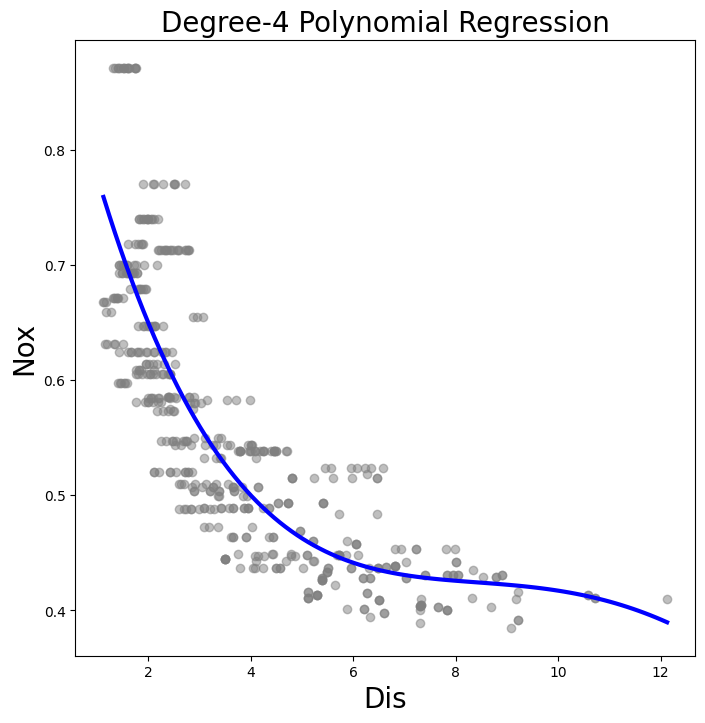

In [ ]:
def plot_nox_fit (dis_df ,basis ,title):
  X = basis.transform (boston)
  Xnew = basis. transform (dis_df)
  M = sm.OLS(nox, X).fit ()
  preds = M. get_prediction (Xnew)
  bands = preds.conf_int (alpha =0.05)
  fig , ax = subplots (figsize =(8 ,8))
  ax.scatter(dis, nox, facecolor ='gray',alpha =0.5)
  for val , ls in zip ([ preds.predicted_mean ,bands [:,0], bands [: ,1]] ,['b','r--','r--']):
    ax.plot(dis_df.values , val , ls , linewidth =3)
    ax. set_title (title , fontsize =20)
    ax. set_xlabel ('Dis', fontsize =20)
    ax. set_ylabel ('Nox', fontsize =20);
    return ax

plot_nox_fit (dis_grid_df ,poly_features , 'Degree-4 Polynomial Regression')




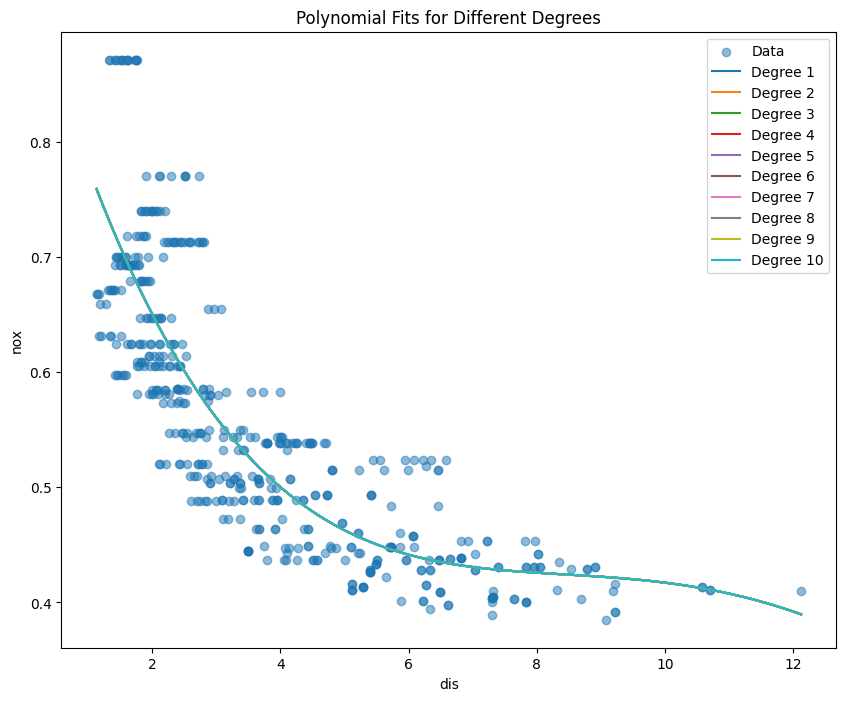

Degree 1: RSS = 1.9329813272985947
Degree 2: RSS = 1.9329813272985947
Degree 3: RSS = 1.9329813272985947
Degree 4: RSS = 1.9329813272985947
Degree 5: RSS = 1.9329813272985947
Degree 6: RSS = 1.9329813272985947
Degree 7: RSS = 1.9329813272985947
Degree 8: RSS = 1.9329813272985947
Degree 9: RSS = 1.9329813272985947
Degree 10: RSS = 1.9329813272985947


In [ ]:
degrees = range(1, 11)
rss_values = []
plt.figure(figsize=(10, 8))
plt.scatter(dis, nox, alpha=0.5, label='Data')

for degree in degrees:
    rss = np.sum(model.resid**2)
    rss_values.append(rss)
    dis_grid = np.linspace(dis.min(), dis.max(), 100)
    dis_grid_df = pd.DataFrame({'dis': dis_grid})
    predictions = model.predict(poly_features.transform(dis_grid_df))

    plt.plot(dis_grid, predictions, label=f'Degree {degree}')

plt.xlabel('dis')
plt.ylabel('nox')
plt.title('Polynomial Fits for Different Degrees')
plt.legend()
plt.show()


for degree, rss in zip(degrees, rss_values):
    print(f'Degree {degree}: RSS = {rss}')

#(c) Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.

In [ ]:
n_folds = 5
cv_scores = []

for degree in degrees:

    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(dis.values.reshape(-1, 1))
    scores = []
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(X_poly):
        X_train, X_test = X_poly[train_index], X_poly[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model = LinearRegression()
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)

        scores.append(mse)

    cv_scores.append(np.mean(scores))

optimal_degree = degrees[np.argmin(cv_scores)]

print(f"Optimal Degree: {optimal_degree}")
print("Cross-Validation Scores:")
for degree, score in zip(degrees, cv_scores):
    print(f"Degree {degree}: {score}")

Optimal Degree: 1
Cross-Validation Scores:
Degree 1: 0.031107486441772525
Degree 2: 0.031361837323252574
Degree 3: 0.03141420152080019
Degree 4: 0.0315280711087077
Degree 5: 0.03201800938922914
Degree 6: 0.031988481286942386
Degree 7: 0.032436918833455806
Degree 8: 0.10430646304634969
Degree 9: 0.03620158648604419
Degree 10: 3.8764820470985355


#In general, you would expect the MSE to decrease initially as the degree increases from better fitting to the training data. However, at some point, the MSE might start to increase again due to overfitting. Cross-validation helps find the degree that balances model complexity and generalization ability. By examining the output, you can identify the optimal degree that provides the best trade-off between fitting the data and avoiding overfitting.

#(d) - Use the bs() function from the ISLP.models module to fit a regression spline to predict nox using dis. Report the output for the fit using four degrees of freedom. How did you choose the knots? Plot the resulting fit.

In [ ]:
from ISLP. transforms import (BSpline as bs,
NaturalSpline )

upper_bound = dis.max()
internal_knots = [knot for knot in [25, 40, 60] if knot <= upper_bound]
bs_ = bs(internal_knots=internal_knots, intercept=True).fit(dis)
bs_dis = bs_.transform(dis)
bs_dis.shape

(506, 4)

In [ ]:
bs_transform = bs(internal_knots=[25, 40, 60], degree=4, intercept=True)
bs_dis = MS(['dis'])
Xbs = bs_dis.fit_transform(boston)
internal_knots = np.quantile(Xbs['dis'], [0.25, 0.5, 0.75])
bs_transform = bs(internal_knots=internal_knots, degree=4, intercept=True)
bs_transform.fit(Xbs['dis'])
Xbs = bs_transform.transform(Xbs['dis'])
M = sm.OLS(nox, Xbs).fit()
M.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     192.6
Date:                Sun, 23 Mar 2025   Prob (F-statistic):          2.83e-137
Time:                        20:30:06   Log-Likelihood:                 704.54
No. Observations:                 506   AIC:                            -1393.
Df Residuals:                     498   BIC:                            -1359.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================================================================================================================================================
                                                                                                                                                          coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[0]     0.6441      0.027     23.562      0.000       0.590       0.698
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[1]     0.7551      0.021     35.681      0.000       0.714       0.797
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[2]     0.6783      0.018     38.128      0.000       0.643       0.713
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[3]     0.5229      0.018     28.590      0.000       0.487       0.559
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[4]     0.4415      0.038     11.527      0.000       0.366       0.517
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[5]     0.4103      0.061      6.709      0.000       0.290       0.530
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[6]     0.4055      0.073      5.569      0.000       0.262       0.548
BSpline(degree=4, intercept=True,
        internal_knots=array([2.100175, 3.20745 , 5.188425]),
        lower_bound=1.1296, upper_bound=12.1265)[7]     0.4118      0.057      7.229      0.000       0.300       0.524
==============================================================================
Omnibus:                       67.097   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               93.446
Skew:                           0.934   Prob(JB):                     5.11e-21
Kurtosis:                       3.971   Cond. No.                         18.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

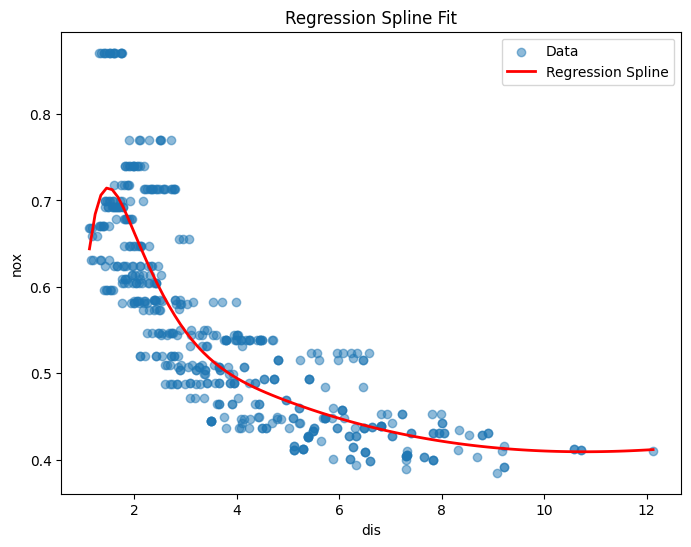

In [ ]:
dis_grid = np.linspace(dis.min(), dis.max(), 100)
Xbs_grid = bs_transform.transform(dis_grid)
predictions = M.predict(Xbs_grid)


plt.figure(figsize=(8, 6))
plt.scatter(dis, nox, alpha=0.5, label='Data')
plt.plot(dis_grid, predictions, color='red', linewidth=2, label='Regression Spline')
plt.xlabel('dis')
plt.ylabel('nox')
plt.title('Regression Spline Fit')
plt.legend()
plt.show()

#In this case, I used three internal knots, resulting in four degrees of freedom (3 internal knots + 1 for the intercept). This choice is a starting point, and might need to experiment with different numbers of knots to find the best balance between model flexibility and overfitting. Can try varying the quantiles (e.g., using deciles instead of quartiles) or using cross-validation to select the optimal number of knots.

#(e) Now fit a regression spline for a range of degrees of freedom, and plot the resulting fits and report the resulting RSS. Describe the results obtained.

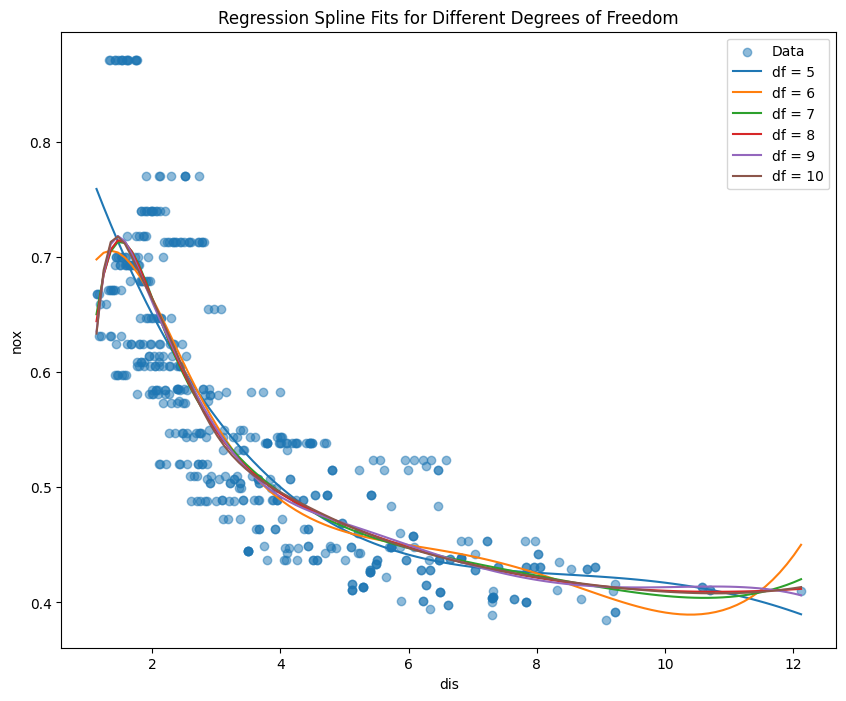

RSS Values:
df = 5: RSS = 1.9329813272985952
df = 6: RSS = 1.8634055091330515
df = 7: RSS = 1.834226400800064
df = 8: RSS = 1.8292649951993054
df = 9: RSS = 1.8286135870342601
df = 10: RSS = 1.8277350723801076

Description of Results:


In [ ]:

degrees_of_freedom = range(5, 11)
rss_values = []
predictions_list = []

for df in degrees_of_freedom:
    bs_transform = bs(df=df, degree=4, intercept=True)

    bs_dis = MS(['dis'])
    Xbs = bs_dis.fit_transform(boston)
    bs_transform.fit(Xbs['dis'])

    Xbs = bs_transform.transform(Xbs['dis'])

    model = sm.OLS(nox, Xbs).fit()

    rss = np.sum(model.resid**2)
    rss_values.append(rss)

    dis_grid = np.linspace(dis.min(), dis.max(), 100)
    Xbs_grid = bs_transform.transform(dis_grid)
    predictions = model.predict(Xbs_grid)
    predictions_list.append(predictions)

plt.figure(figsize=(10, 8))
plt.scatter(dis, nox, alpha=0.5, label='Data')

for i, df in enumerate(degrees_of_freedom):
    plt.plot(dis_grid, predictions_list[i], label=f'df = {df}')

plt.xlabel('dis')
plt.ylabel('nox')
plt.title('Regression Spline Fits for Different Degrees of Freedom')
plt.legend()
plt.show()

print("RSS Values:")
for df, rss in zip(degrees_of_freedom, rss_values):
    print(f'df = {df}: RSS = {rss}')

print("\nDescription of Results:")

#As the degrees of freedom increase, the regression spline becomes more flexible and better fits the data, leading to a decrease in RSS. However, after a certain point, increasing the degrees of freedom might lead to overfitting, where the spline starts to capture noise in the data rather than the underlying pattern. The optimal degrees of freedom would be the one that minimizes the RSS without overfitting.

#(f) - Perform cross-validation or another approach in order to select the best degrees of freedom for a regression spline on this data. Describe your results.

In [ ]:
degrees_of_freedom = range(5, 11)
n_folds = 5
cv_scores = []

for df in degrees_of_freedom:
    scores = []
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_index, test_index in kf.split(dis):
        X_train = dis.iloc[train_index]
        X_test = dis.iloc[test_index]
        y_train = nox.iloc[train_index]
        y_test = nox.iloc[test_index]

        bs_transform = bs(df=df, degree=4, intercept=True)
        bs_transform.fit(X_train)

        X_train_bs = bs_transform.transform(X_train)
        X_test_bs = bs_transform.transform(X_test)

        model = sm.OLS(y_train, X_train_bs).fit()

        y_pred = model.predict(X_test_bs)
        mse = mean_squared_error(y_test, y_pred)
        scores.append(mse)

    cv_scores.append(np.mean(scores))

optimal_df = degrees_of_freedom[np.argmin(cv_scores)]

print(f"Optimal Degrees of Freedom: {optimal_df}")
print("Cross-Validation Scores (MSE):")
for df, score in zip(degrees_of_freedom, cv_scores):
    print(f"df = {df}: {score}")

Optimal Degrees of Freedom: 7
Cross-Validation Scores (MSE):
df = 5: 0.0038919289814631406
df = 6: 0.0038062403076376656
df = 7: 0.0037373967399181225
df = 8: 0.003760767820676576
df = 9: 0.0037802850869976547
df = 10: 0.0037864904981798815


#From the list of MSE we can see that the model with 7 degrees of freedom had the lowest MSE making it the best one to use.

#**Chapter 8 Question 10**

#10 We now use boosting to predict Salary in the Hitters data set.
#(a) - Remove the observations for whom the salary information is unknown, and then log-transform the salaries.


In [ ]:
Hitters = pd.DataFrame(load_data('Hitters'))
Hitters = Hitters.dropna(subset=['Salary'])
Hitters['Salary'] = np.log(Hitters['Salary'])
Hitters['League'] = Hitters['League'].map({'A': 1, 'N': 0})
Hitters['Division'] = Hitters['Division'].map({'W': 1, 'E': 0})
Hitters['NewLeague'] = Hitters['NewLeague'].map({'A': 1, 'N': 0})
Hitters.info()
len(Hitters)

Hitters.head()


<class 'pandas.core.frame.DataFrame'>
Index: 263 entries, 1 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      263 non-null    int64   
 1   Hits       263 non-null    int64   
 2   HmRun      263 non-null    int64   
 3   Runs       263 non-null    int64   
 4   RBI        263 non-null    int64   
 5   Walks      263 non-null    int64   
 6   Years      263 non-null    int64   
 7   CAtBat     263 non-null    int64   
 8   CHits      263 non-null    int64   
 9   CHmRun     263 non-null    int64   
 10  CRuns      263 non-null    int64   
 11  CRBI       263 non-null    int64   
 12  CWalks     263 non-null    int64   
 13  League     263 non-null    category
 14  Division   263 non-null    category
 15  PutOuts    263 non-null    int64   
 16  Assists    263 non-null    int64   
 17  Errors     263 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  263 non-null    categor

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,0,1,632,43,10,6.163315,0
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,1,1,880,82,14,6.173786,1
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,0,0,200,11,3,6.214608,0
4,321,87,10,39,42,30,2,396,101,12,48,46,33,0,0,805,40,4,4.516339,0
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,1,1,282,421,25,6.620073,1


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=Hitters)

https://docs.google.com/spreadsheets/d/1sgw2llSbg6d3-Vx8r1_bx_m-D6b9IGocRCM3QP_3EkI/edit#gid=0


#(b) Create a training set consisting of the first 200 observations, and a test set consisting of the remaining observations.

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(Hitters.drop('Salary', axis=1),  Hitters['Salary'],test_size=len(Hitters) - 200, random_state=0)

#(c) Perform boosting on the training set with 1,000 trees for a range of values of the shrinkage parameter λ. Produce a plot withdifferent shrinkage values on the x-axis and the corresponding training set MSE on the y-axis.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import accuracy_score, log_loss
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor as GBR
from ISLP.bart import BART
from ISLP import load_data
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


In [ ]:
boost_hitters = GBR( n_estimators =1000 ,learning_rate =0.001 ,max_depth =3, random_state =0)
boost_hitters.fit(x_train , y_train)

GradientBoostingRegressor(learning_rate=0.001, n_estimators=1000,
                          random_state=0)

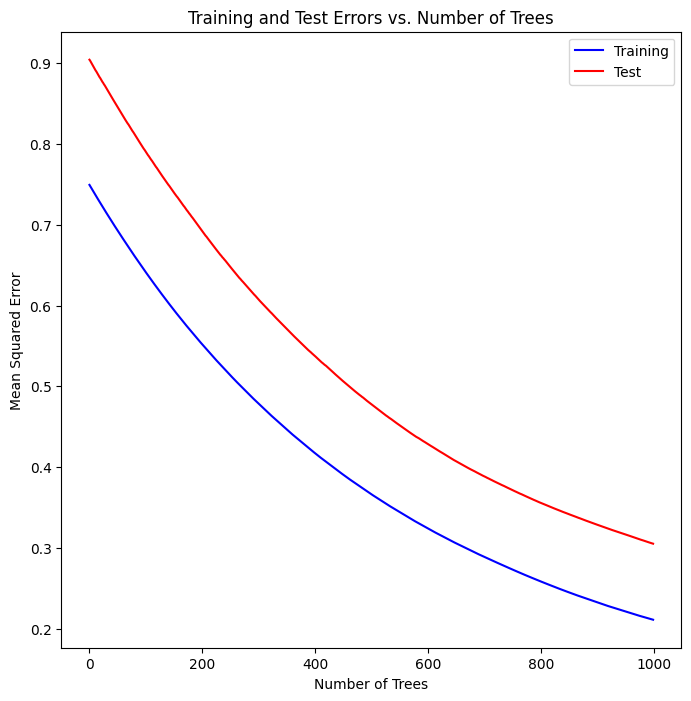

In [ ]:
test_error = np.zeros_like(boost_hitters.train_score_)
for idx, y_ in enumerate(boost_hitters.staged_predict(x_test)):
    test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_hitters.train_score_.shape[0])
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(plot_idx, boost_hitters.train_score_, 'b', label='Training')
ax.plot(plot_idx, test_error, 'r', label='Test')
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Mean Squared Error')
ax.set_title('Training and Test Errors vs. Number of Trees')
ax.legend()
plt.show()

#(d) Produce a plot with different shrinkage values on the x-axis and the corresponding test set MSE on the y-axis.

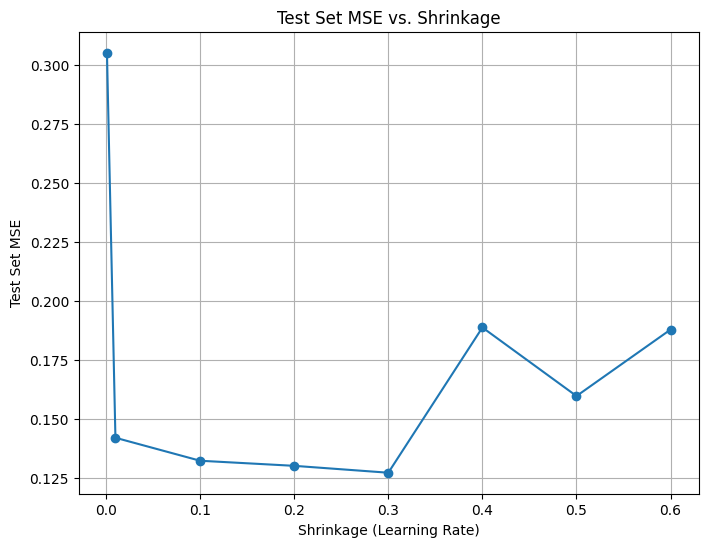

Best Boosting Test MSE: 0.1273426824016311


In [ ]:
learning_rates = [0.001, 0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
test_mse_values = []

for lr in learning_rates:
    boost_hitters = GBR(n_estimators=1000, learning_rate=lr, max_depth=3, random_state=0)
    boost_hitters.fit(x_train, y_train)
    y_pred = boost_hitters.predict(x_test)
    test_mse = mean_squared_error(y_test, y_pred)
    test_mse_values.append(test_mse)

plt.figure(figsize=(8, 6))
plt.plot(learning_rates, test_mse_values, marker='o')
plt.xlabel('Shrinkage (Learning Rate)')
plt.ylabel('Test Set MSE')
plt.title('Test Set MSE vs. Shrinkage')
plt.grid(True)
plt.show()

best_boosting_mse = min(test_mse_values)
print(f"Best Boosting Test MSE: {best_boosting_mse}")

# (e) - Compare the test MSE of boosting to the test MSE that results from applying two of the regression approaches seen in Chapters 3 and 6.

#Multiple Linear Regression (CH3)

In [ ]:
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)
y_pred_linear = linear_reg.predict(x_test)
test_mse_linear = mean_squared_error(y_test, y_pred_linear)


print(f"Best Boosting Test MSE: {best_boosting_mse}")
print(f"Multiple Linear Regression Test MSE: {test_mse_linear}")

Best Boosting Test MSE: 0.1273426824016311
Multiple Linear Regression Test MSE: 0.4554944998613735


#Best Subset Selection (CH6)

In [ ]:
def processSubset(feature_set):
    x_train_subset = x_train[list(feature_set)].copy()

    x_train_subset = x_train_subset.apply(pd.to_numeric, errors='coerce')

    x_train_subset = x_train_subset.dropna()

    for col in x_train_subset.select_dtypes(include=['object']).columns:
        x_train_subset = pd.get_dummies(x_train_subset, columns=[col], drop_first=True)

    model = sm.OLS(y_train.loc[x_train_subset.index], x_train_subset)
    regr = model.fit()
    mse = mean_squared_error(y_train.loc[x_train_subset.index], regr.predict(x_train_subset))
    return {"model": regr, "MSE": mse}
    return {"model": regr, "MSE": mse}

def getBest(k):
    tic = time.time()
    results = []
    for combo in itertools.combinations(x_train.columns, k):
        results.append(processSubset(combo))

    models = pd.DataFrame(results)
    best_model = models.loc[models['MSE'].argmin()]

    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")

    return best_model


p = len(x_train.columns)

models_best = pd.DataFrame(columns=["MSE", "model"])

tic = time.time()
for i in range(1, p + 1):
    models_best.loc[i] = getBest(i)

toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

best_subset_model = models_best.loc[models_best['MSE'].argmin()]
best_subset_coefs = best_subset_model['model'].params
selected_predictors = best_subset_coefs.index.tolist()


Processed 19 models on 1 predictors in 0.10597586631774902 seconds.
Processed 171 models on 2 predictors in 0.7204737663269043 seconds.
Processed 969 models on 3 predictors in 4.042941093444824 seconds.
Processed 3876 models on 4 predictors in 18.7140474319458 seconds.
Processed 11628 models on 5 predictors in 56.319936990737915 seconds.
Processed 27132 models on 6 predictors in 132.8776273727417 seconds.
Processed 50388 models on 7 predictors in 258.55347180366516 seconds.
Processed 75582 models on 8 predictors in 397.6106708049774 seconds.
Processed 92378 models on 9 predictors in 499.40720868110657 seconds.
Processed 92378 models on 10 predictors in 516.0030035972595 seconds.
Processed 75582 models on 11 predictors in 431.1236653327942 seconds.
Processed 50388 models on 12 predictors in 296.6264326572418 seconds.
Processed 27132 models on 13 predictors in 162.0386245250702 seconds.
Processed 11628 models on 14 predictors in 72.45824122428894 seconds.
Processed 3876 models on 15 pred

In [ ]:

for index, row in models_best.iterrows():
    print(f"Model with {index} predictors:")
    print("Predictors:", row['model'].params.index.tolist())
    print("Coefficients:", row['model'].params.values.tolist())
    print("-" * 20)

Model with 1 predictors:
Predictors: ['AtBat']
Coefficients: [0.013188071550604832]
--------------------
Model with 2 predictors:
Predictors: ['AtBat', 'Years']
Coefficients: [0.009597967383617883, 0.23103406840566826]
--------------------
Model with 3 predictors:
Predictors: ['AtBat', 'Years', 'CAtBat']
Coefficients: [0.009748113853353634, 0.48001696726171006, -0.0006845366243511259]
--------------------
Model with 4 predictors:
Predictors: ['AtBat', 'Years', 'CAtBat', 'Division']
Coefficients: [0.009384405456952325, 0.4617039451938081, -0.0006543729162325226, 0.4107641625438212]
--------------------


#Boosting had much better mse compared to the best model from best subset selection

#(f) - Which variables appear to be the most important predictors in the boosted model?

In [ ]:
feature_importances = boost_hitters.feature_importances_
feature_importance_df = pd.DataFrame({'Predictor': x_train.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by=['Importance'], ascending=False)
print(feature_importance_df.head())


   Predictor  Importance
7     CAtBat    0.564361
1       Hits    0.109212
11      CRBI    0.097821
9     CHmRun    0.040607
5      Walks    0.036025


#(g) Now apply bagging to the training set. What is the test set MSE for this approach?

In [ ]:
from sklearn.ensemble import BaggingRegressor


bagging_model = BaggingRegressor(estimator=DecisionTreeRegressor(),
                                 n_estimators=100,
                                 random_state=0)
bagging_model.fit(x_train, y_train)

y_pred_bagging = bagging_model.predict(x_test)
test_mse_bagging = mean_squared_error(y_test, y_pred_bagging)

print(f"Bagging Test Set MSE: {test_mse_bagging}")

Bagging Test Set MSE: 0.1376998721647624
